# Import

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import utils

import matplotlib.pyplot as plt
import plotly.graph_objs as go
from importlib import reload
from tqdm import tqdm

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (8, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)
%config InlineBackend.figure_format = "retina"

import matplotlib
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amsfonts}')
dpi = 300
fs = 14
fsL = 19
plt.rcParams["font.size"] = fs

## Parameters

import pickle

S0 = 2820; Y0 = 50_000; trade_size = 100; fee = 0.01 * trade_size * S0

params_glob = {'sigma': 0.0569*(2820), 'rate': 0, 'T': 1, 'S0': S0}
params_LP = {'a0': 1. , 'a1': 10., 'a2': 10., 'ksi': trade_size, 'X0': Y0 * S0, 'Y0': Y0, 'gamma': 10**(-6), 'fees_coeff': fee}
params_grid = {'n_paths': 10_000, 'n_steps': 1440}

params_env = {'glob': params_glob,
              'lp': params_LP,
              'grid': params_grid}

with open('params_env.pkl', 'wb') as f:
    pickle.dump(params_env, f)

In [2]:
import pickle

with open('params_env.pkl', 'rb') as f:
    params_env = pickle.load(f)

params_glob = params_env['glob']
params_LP = params_env['lp']
params_grid = params_env['grid']
BM_type = 'arithmetic'  # 'geometric' or 'arithmetic'

# AMM Simulation Process

## Optimal exit time by Longstaff-Schwartz

In [3]:
np.random.seed(314)

In [4]:
amm_solver_obj = utils.Solver(**{**params_glob, **params_grid, **params_LP})
amm_solver_obj.amm_model(BM_type=BM_type)

# Sample paths

In [5]:
timesteps = np.linspace(0, params_glob['T'], params_grid['n_steps'] + 1)
nsim = 1
amm_paths_S = amm_solver_obj.get_paths()['external_mid_price_S']
amm_paths_Z = amm_solver_obj.get_paths()['asset_Z']
amm_paths_Y = amm_solver_obj.get_paths()['asset_Y']
amm_paths_X = amm_solver_obj.get_paths()['asset_X']
fees_R = amm_solver_obj.get_paths()['fees']

IL =  -(amm_paths_X + amm_paths_Y*amm_paths_S 
        - (np.repeat(np.reshape(amm_paths_X[:,0],(params_grid['n_paths'],1)),params_grid['n_steps']+1,axis=1) + np.repeat(np.reshape(amm_paths_Y[:,0],(params_grid['n_paths'],1)),params_grid['n_steps']+1,axis=1)*amm_paths_S))


qtl_Y = np.zeros((len(timesteps),3))
qtl_IL = np.zeros((len(timesteps),3))
qtl_fees = np.zeros((len(timesteps),3))
qtl_Z = np.zeros((len(timesteps),3))
qtl_S = np.zeros((len(timesteps),3))

for it, t in enumerate(timesteps):
    qtl_Y[it, :] = np.quantile(amm_paths_Y[:,it],[0.05,0.5,0.95],axis=0)
    qtl_IL[it, :] = np.quantile(IL[:,it],[0.05,0.5,0.95],axis=0)
    qtl_fees[it, :] = np.quantile(fees_R[:,it],[0.05,0.5,0.95],axis=0)
    qtl_Z[it, :] = np.quantile(amm_paths_Z[:,it],[0.05,0.5,0.95],axis=0)
    qtl_S[it, :] = np.quantile(amm_paths_S[:,it],[0.05,0.5,0.95],axis=0)

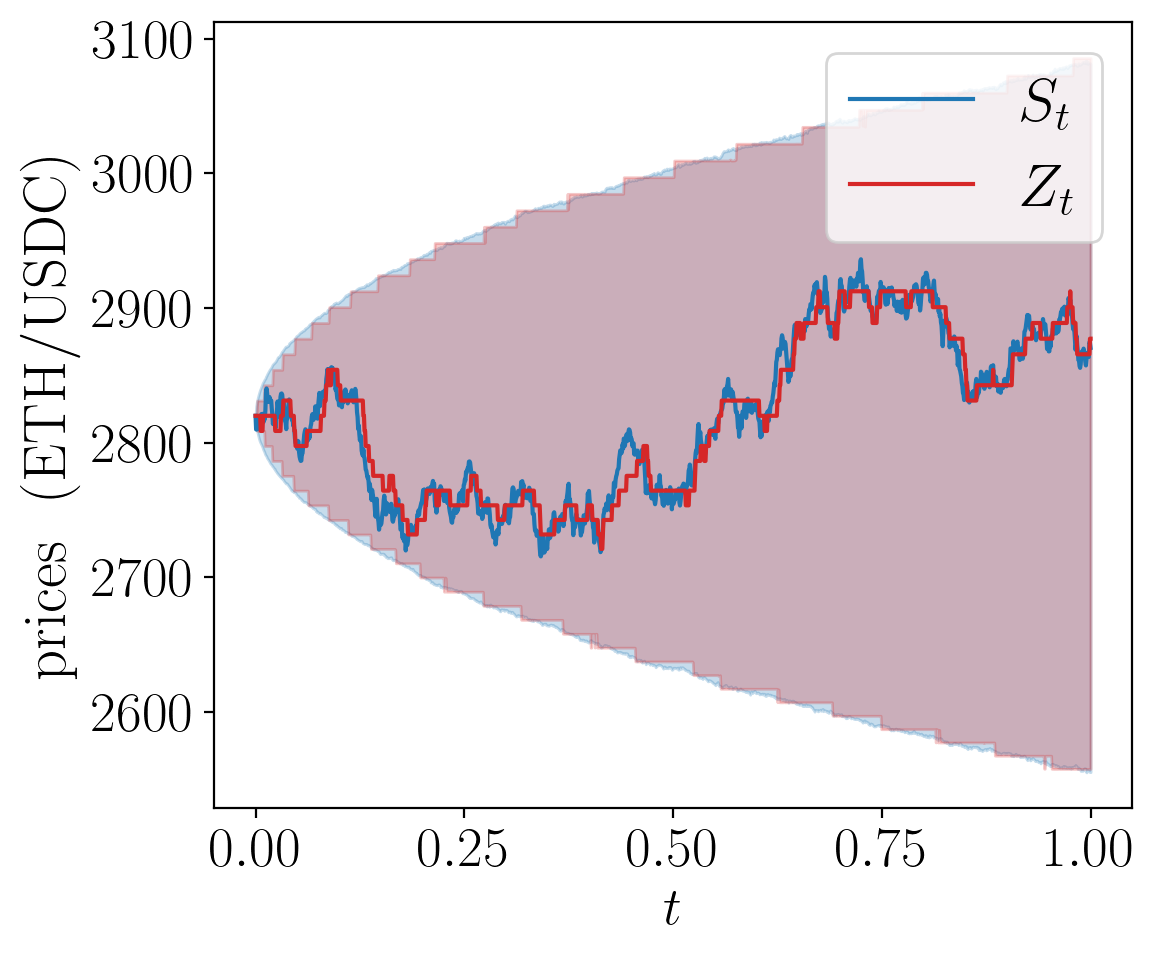

In [6]:
fig, axs = plt.subplots(1, 1, sharex=True, figsize=(6,5))
plt.plot(timesteps, amm_paths_S[nsim,:], label=r'$S_t$', color ='tab:blue')
plt.plot(timesteps, amm_paths_Z[nsim,:], label=r'$Z_t$', color ='tab:red')
plt.fill_between(timesteps,qtl_S[:,0],qtl_S[:,-1], color='tab:blue', alpha=0.25)
plt.fill_between(timesteps,qtl_Z[:,0],qtl_Z[:,-1], color='tab:red', alpha=0.25)
plt.xlabel(r'$t$', fontsize = fsL)
plt.ylabel(r'$\mathrm{prices}$~~$\mathrm{(ETH/USDC)}$', fontsize = fsL+3)
plt.tight_layout()
plt.legend(fontsize = fsL+3, loc = 'upper right')
plt.savefig(f'figures/S-Z-paths.pdf', format="pdf", dpi=dpi)
plt.show()

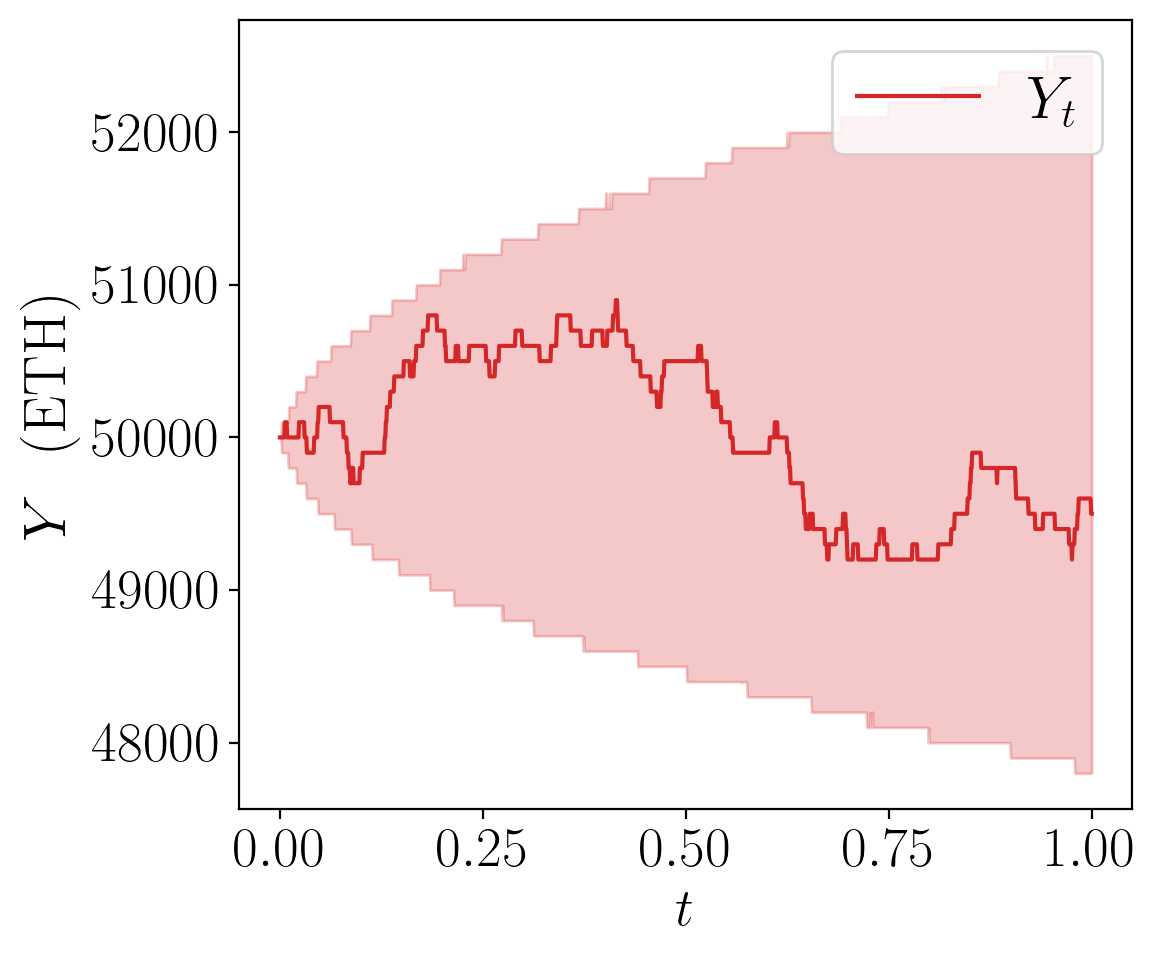

In [7]:
fig, axs = plt.subplots(1, 1, sharex=True, figsize=(6,5))
plt.plot(timesteps, amm_paths_Y[nsim,:], label=r'$Y_t$', color ='tab:red')
plt.fill_between(timesteps,qtl_Y[:,0],qtl_Y[:,-1], color='tab:red', alpha=0.25)
plt.xlabel(r'$t$', fontsize = fsL)
plt.ylabel(r'$Y$~~$\mathrm{(ETH)}$', fontsize = fsL+3)
plt.tight_layout()
plt.legend(fontsize = fsL+3, loc = 'upper right')
plt.savefig(f'figures/Y-paths.pdf', format="pdf", dpi=dpi)
plt.show()

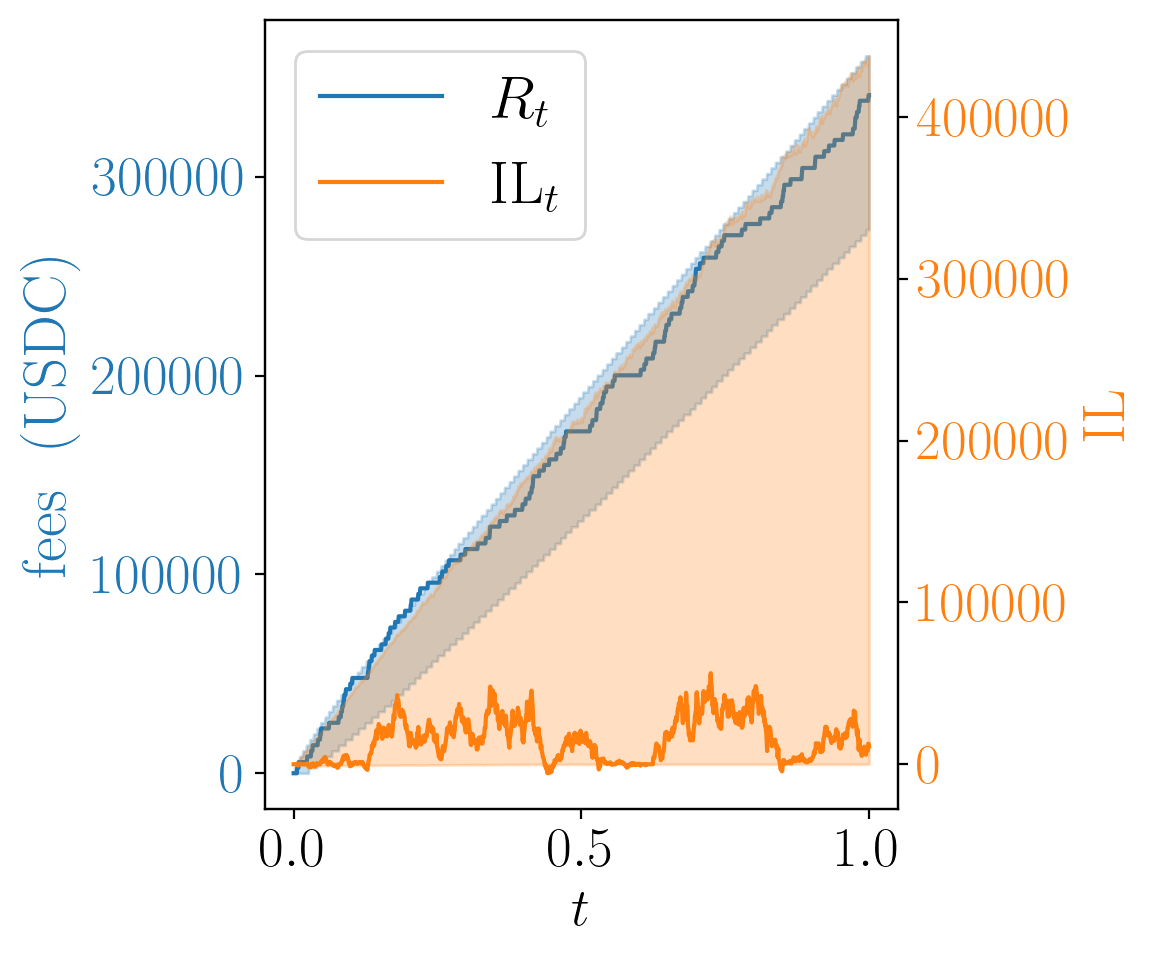

In [8]:
nsim =1
fig, ax1 = plt.subplots(1, 1, sharex=True, figsize=(6, 5))

# Primary y-axis: fees_R
ax1.plot(timesteps, fees_R[nsim, :], label=r'$R_t$', color='tab:blue')
ax1.fill_between(timesteps, qtl_fees[:, 0], qtl_fees[:, -1], color='tab:blue', alpha=0.25)
ax1.set_xlabel(r'$t$', fontsize=fsL)
ax1.set_ylabel(r'$\mathrm{fees}$~~$\mathrm{(USDC)}$', fontsize=fsL + 3, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Twin y-axis: IL
ax2 = ax1.twinx()
ax2.plot(timesteps, IL[nsim, :], label=r'$\mathrm{IL}_t$', color='tab:orange')
ax2.fill_between(timesteps, qtl_IL[:, 0], qtl_IL[:, -1], color='tab:orange', alpha=0.25)
ax2.set_ylabel(r'$\mathrm{IL}$', fontsize=fsL + 3, color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.tight_layout()
#plt.legend(fontsize = fsL+3, loc = 'upper left')
# Collect handles and labels from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_lines = lines1 + lines2
all_labels = labels1 + labels2

# Add combined legend
ax1.legend(all_lines, all_labels, fontsize=fsL+3, loc='upper left')
plt.savefig(f'figures/fees-paths.pdf', format="pdf", dpi=dpi)
plt.show()

# Exit boundary plot

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### Stressing $\mathfrak{r}$ a little

In [12]:
def a1a2_sensitivity(rnew, kappa, params_LP):
    rbaseline = params_LP['fees_coeff']+0.
    a1 = params_LP['a1']+0.
    a2 = params_LP['a2']+0.
    a1 = a1*np.exp(-kappa*(rnew - rbaseline))
    a2 = a2*np.exp(-kappa*(rnew - rbaseline))
    return a1,a2

In [26]:
fee_new = 1/2*params_LP['fees_coeff']
a1_new, a2_new = a1a2_sensitivity(fee_new, kappa = 1e-4, params_LP = params_LP)

params_LP_aux = params_LP.copy()
params_LP_aux['fees_coeff'] = fee_new
params_LP_aux['a1'] = a1_new
params_LP_aux['a2'] = a2_new

amm_solver_aux = utils.Solver(**{**params_glob, **params_grid, **params_LP_aux})
amm_solver_aux.amm_model(BM_type=BM_type)

In [27]:
# Solving the AMM problem using Longstaff-Schwartz method
amm_paths = amm_solver_aux.get_paths()['amm_model_0']
amm_paths_S = amm_solver_aux.get_paths()['external_mid_price_S']
amm_paths_Y = amm_solver_aux.get_paths()['asset_Y']
amm_paths_X = amm_solver_aux.get_paths()['asset_X']
res_LS = amm_solver_aux.longstaff_schwartz(paths=amm_paths, paths_S=amm_paths_S, 
                                            paths_Y=amm_paths_Y, deg=2)

# Prepare data for plotting
external_mid_price_S_LS = amm_solver_aux.get_paths()['external_mid_price_S']
asset_Z = amm_solver_aux.get_paths()['asset_Z']
fees_R = amm_solver_aux.get_paths()['fees']

IL =  -(amm_paths_X + amm_paths_Y*amm_paths_S 
        - (np.repeat(np.reshape(amm_paths_X[:,0],(params_grid['n_paths'],1)),params_grid['n_steps']+1,axis=1) + np.repeat(np.reshape(amm_paths_Y[:,0],(params_grid['n_paths'],1)),params_grid['n_steps']+1,axis=1)*amm_paths_S))

input_params = amm_solver_aux.get_params()

t_ = np.zeros(shape=(params_grid['n_paths'], params_grid['n_steps'] + 1))
t_[:,:] = np.linspace(0, params_glob['T'], params_grid['n_steps'] + 1)

value_function_LS = res_LS['V_matrix']

Yaux = external_mid_price_S_LS #- asset_Z
#Zaux = amm_paths_Y 
Zaux = fees_R - IL

x = t_[np.arange(params_grid['n_paths']),   res_LS['stopping_time']]       
y = Yaux[np.arange(params_grid['n_paths']), res_LS['stopping_time']] 
z = Zaux[np.arange(params_grid['n_paths']), res_LS['stopping_time']]

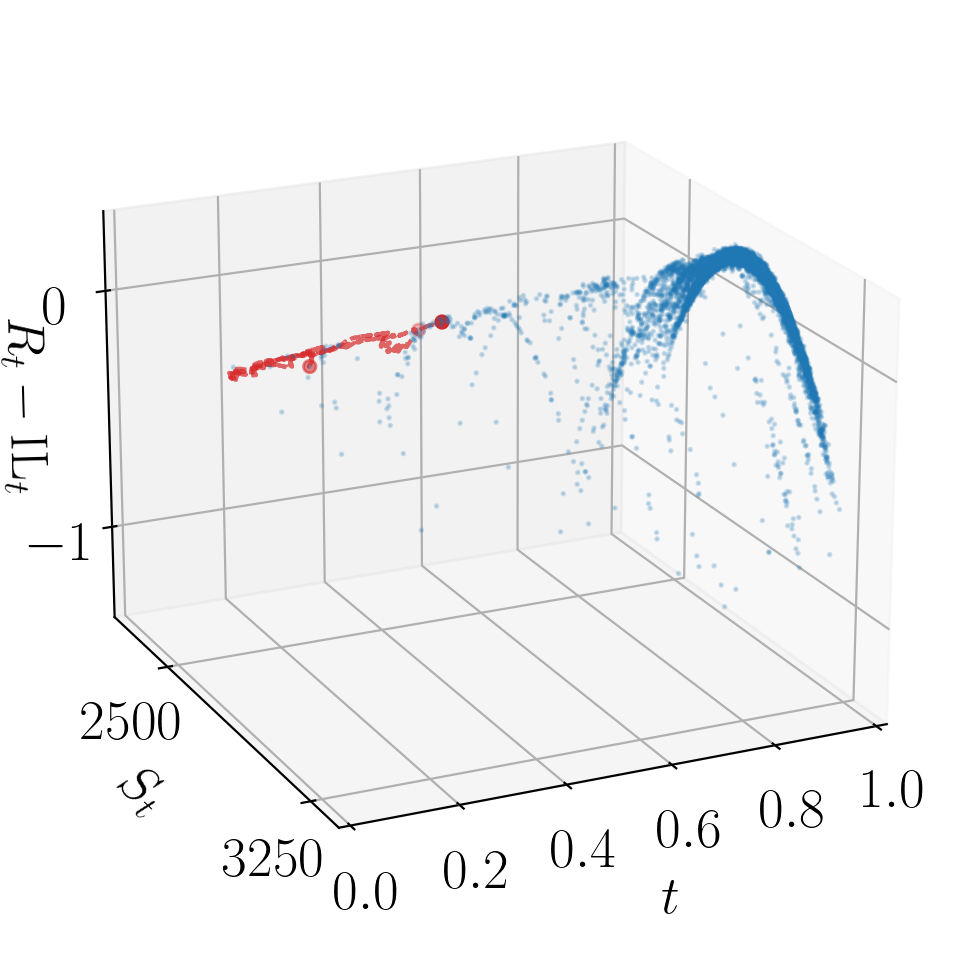

In [28]:
# Set figure size and create 3D axis
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter
ax.scatter(x, y, z, c='tab:blue', s=1, alpha=0.2)

# Set axis labels
ax.set_xlabel(r'$t$', fontsize=fsL, labelpad=12)
ax.set_ylabel(r'$S_t$', fontsize=fsL, labelpad=4)
ax.set_zlabel(r'$R_t - \mathrm{IL}_t$', fontsize=fsL, labelpad=-1)


# Set axis limits
ax.set_xlim([0, params_glob['T']])

np.random.seed(123)


xofinterest = np.argwhere((x < 0.5)).ravel()#*(z<-0.5e6)
if len(xofinterest)>3:
    xofinterest = np.random.choice(xofinterest, size=3, replace=False)
for ix in xofinterest:
    tau = res_LS['stopping_time'][ix]
    ax.plot3D(t_[ix,:tau], Yaux[ix,:tau], Zaux[ix,:tau], '--', c='tab:red', alpha= 0.7)

    

ax.scatter(x[xofinterest], y[xofinterest], z[xofinterest], c="tab:red")

# Set view angle (optional, similar to camera eye)
ax.view_init(elev=20, azim=65)  # approximate Plotly camera
# Finalize
ax.set_yticks([2500, 3250])
ax.set_zticks([0, -1e6])

plt.tight_layout()
ax.invert_xaxis()
plt.savefig('figures/3d-plot-exit-time.png', format='png', dpi=dpi)
plt.show()

# The global stress function

In [29]:
def stress_parameter(multiplier=np.array([1/2,2]), text_array = ['$\sigma$/2', '2\,$\sigma$'], 
                          params_type = 'glob', parameter_to_stress = 'sigma', seed = 123, verbose = False):
    mean_tau = np.zeros_like(multiplier)
    mean_fee = np.zeros_like(multiplier)
    percentage_stopped = np.zeros_like(multiplier)
    mean_IL = np.zeros_like(multiplier)
    mean_perf = np.zeros_like(multiplier)

    std_tau = np.zeros_like(multiplier)
    std_fee = np.zeros_like(multiplier)
    std_IL = np.zeros_like(multiplier)
    std_perf = np.zeros_like(multiplier)


    for im, mult in tqdm(enumerate(multiplier), total=len(multiplier)):
        np.random.seed(314)
        
        if parameter_to_stress == 'fees_coeff':
            param_new = mult * params_env[params_type][parameter_to_stress]
            params_aux = params_env[params_type].copy()
            params_aux[parameter_to_stress] = param_new
            
            a1_new, a2_new = a1a2_sensitivity(param_new, kappa = 1e-4, params_LP = params_env[params_type])
            
            params_aux['a1'] = a1_new
            params_aux['a2'] = a2_new
            
        else:
            param_new = mult * params_env[params_type][parameter_to_stress]
            params_aux = params_env[params_type].copy()
            params_aux[parameter_to_stress] = param_new
        
        if params_type=='glob':
            amm_solver_aux = utils.Solver(**{**params_aux, **params_grid, **params_LP})
        else:
            amm_solver_aux = utils.Solver(**{**params_glob, **params_grid, **params_aux})
        amm_solver_aux.amm_model(BM_type=BM_type)
        
        amm_paths = amm_solver_aux.get_paths()['amm_model_0']
        amm_paths_S = amm_solver_aux.get_paths()['external_mid_price_S']
        amm_paths_Y = amm_solver_aux.get_paths()['asset_Y']
        amm_paths_X = amm_solver_aux.get_paths()['asset_X']
        asset_Z = amm_solver_aux.get_paths()['asset_Z']
        
        res_LS = amm_solver_aux.longstaff_schwartz(paths=amm_paths, paths_S=amm_paths_S, paths_Y=amm_paths_Y, deg=2)
        
        fees_R = amm_solver_aux.get_paths()['fees']
        
        t_ = np.zeros(shape=(params_grid['n_paths'], params_grid['n_steps'] + 1))
        t_[:,:] = np.linspace(0, params_glob['T'], params_grid['n_steps'] + 1)

        value_function_LS = res_LS['V_matrix']

        x = t_[np.arange(params_grid['n_paths']), res_LS['stopping_time']]       
        z = fees_R[np.arange(params_grid['n_paths']), res_LS['stopping_time']] 

        IL =  -(amm_paths_X + amm_paths_Y*amm_paths_S 
            - (np.repeat(np.reshape(amm_paths_X[:,0],(params_grid['n_paths'],1)),params_grid['n_steps']+1,axis=1) + np.repeat(np.reshape(amm_paths_Y[:,0],(params_grid['n_paths'],1)),params_grid['n_steps']+1,axis=1)*amm_paths_S))

        IL = np.take_along_axis(IL, np.array(res_LS['stopping_time'])[:, None], axis=1).flatten()
        fees_R = np.take_along_axis(fees_R, np.array(res_LS['stopping_time'])[:, None], axis=1).flatten()

        mean_tau[im] = np.mean(x)
        mean_fee[im] = np.mean(z)
        percentage_stopped[im] = np.mean(x<1) 
        mean_IL[im] = np.mean(IL)

        std_tau[im] = np.std(x)
        std_fee[im] = np.std(z)
        std_IL[im] = np.std(IL)
        
        mean_perf[im] = np.mean(z-IL)
        std_perf[im] = np.std(z-IL)
    df_data = pd.DataFrame({
        'parameter': multiplier * params_env[params_type][parameter_to_stress],
        'Mean tau': mean_tau,
        'Mean fee': mean_fee,     
        'Mean IL': mean_IL,
        'std tau': std_tau,
        'std fee': std_fee,     
        'std IL': std_IL,
        'Mean perf': mean_perf,
        'std perf': std_perf,
    })
    df = pd.DataFrame({
        'Parameter': text_array,
        'Mean Tau': [f"{mean:.2f} ({std:.2f})" for mean, std in zip(mean_tau, std_tau)],
        'Mean Fee': [f"{int(fee):,} ({int(std):,})" for fee, std in zip(mean_fee, std_fee)],
        'Mean IL': [f"{int(IL):,} ({int(std):,})" for IL, std in zip(mean_IL, std_IL)],
    })

    # Export to LaTeX
    latex_output = df.to_latex(index=False, float_format="%.3f")
    if verbose:
        return latex_output, df_data
    else:
        return latex_output

# Stressing $\sigma$

In [30]:
text_array = ['$\sigma$/5', '$\sigma$/4', '$\sigma$/3','$\sigma$/2','$\sigma$','$2\,\sigma$','$3\,\sigma$','$4\,\sigma$','$5\,\sigma$']
multiplier = np.array([1/5,1/4,1/3,1/2,1,2,3,4,5])
latex_output = stress_parameter(multiplier=multiplier, text_array = text_array, 
                          params_type = 'glob', parameter_to_stress = 'sigma', seed = 123)
print(latex_output)

100%|█████████████████████████████████████████| 9/9 [00:46<00:00,  5.12s/it]

\begin{tabular}{llll}
\toprule
Parameter & Mean Tau & Mean Fee & Mean IL \\
\midrule
$\sigma$/5 & 1.00 (0.00) & 161,765 (22,320) & 4,364 (6,419) \\
$\sigma$/4 & 1.00 (0.00) & 168,343 (22,217) & 6,912 (10,024) \\
$\sigma$/3 & 1.00 (0.00) & 181,148 (21,806) & 12,422 (17,830) \\
$\sigma$/2 & 1.00 (0.00) & 210,406 (22,535) & 28,177 (40,154) \\
$\sigma$ & 1.00 (0.01) & 316,222 (26,930) & 112,635 (157,844) \\
$2\,\sigma$ & 0.51 (0.27) & 273,003 (144,005) & 202,999 (372,645) \\
$3\,\sigma$ & 0.01 (0.01) & 3,599 (9,363) & 2,449 (13,042) \\
$4\,\sigma$ & 0.00 (0.00) & 1,794 (3,984) & 1,304 (7,411) \\
$5\,\sigma$ & 0.00 (0.00) & 532 (1,198) & 420 (1,401) \\
\bottomrule
\end{tabular}



# Stressing $\mathfrak{r}$ (fee)

In [31]:
text_array = ['$\fee$/5', '$\fee$/4', '$\fee$/3','$\fee$/2','$\fee$','$2\,\fee$','$3\,\fee$','$4\,\fee$','$5\,\fee$']
latex_output = stress_parameter(multiplier=multiplier, text_array = text_array, 
                          params_type = 'lp', parameter_to_stress = 'fees_coeff', seed = 123)
print(latex_output)

100%|█████████████████████████████████████████| 9/9 [00:41<00:00,  4.56s/it]

\begin{tabular}{llll}
\toprule
Parameter & Mean Tau & Mean Fee & Mean IL \\
\midrule
$ee$/5 & 0.01 (0.01) & 373 (750) & 173 (1,308) \\
$ee$/4 & 0.04 (0.05) & 3,027 (5,099) & 2,239 (11,377) \\
$ee$/3 & 0.11 (0.12) & 12,578 (14,578) & 8,437 (35,736) \\
$ee$/2 & 0.96 (0.09) & 166,560 (20,956) & 105,643 (141,534) \\
$ee$ & 1.00 (0.01) & 316,222 (26,930) & 112,635 (157,844) \\
$2\,ee$ & 1.00 (0.00) & 530,160 (50,735) & 113,269 (161,299) \\
$3\,ee$ & 1.00 (0.00) & 670,137 (71,973) & 113,126 (161,712) \\
$4\,ee$ & 1.00 (0.00) & 755,901 (91,748) & 112,825 (161,819) \\
$5\,ee$ & 1.00 (0.00) & 802,518 (109,834) & 112,407 (161,782) \\
\bottomrule
\end{tabular}



# Stressing $a_1$ (noise trading)

In [16]:
text_array = ['$a_1$/5', '$a_1$/4', '$a_1$/3','$a_1$/2','$a_1$','$2\,a_1$','$3\,a_1$','$4\,a_1$','$5\,a_1$']
latex_output = stress_parameter(multiplier=multiplier, text_array = text_array, 
                          params_type = 'lp', parameter_to_stress = 'a1', seed = 123)
print(latex_output)

100%|█████████████████████████████████████████████| 9/9 [00:39<00:00,  4.37s/it]


\begin{tabular}{llll}
\toprule
Parameter & Mean Tau & Mean Fee & Mean IL \\
\midrule
$a_1$/5 & 1.00 (0.01) & 296,407 (26,305) & 112,619 (157,946) \\
$a_1$/4 & 1.00 (0.01) & 297,518 (26,328) & 112,633 (157,824) \\
$a_1$/3 & 1.00 (0.01) & 299,641 (26,392) & 112,652 (158,199) \\
$a_1$/2 & 1.00 (0.01) & 303,577 (26,514) & 112,625 (157,865) \\
$a_1$ & 1.00 (0.01) & 316,222 (26,930) & 112,635 (157,844) \\
$2\,a_1$ & 1.00 (0.01) & 343,925 (27,871) & 112,757 (158,040) \\
$3\,a_1$ & 1.00 (0.01) & 373,822 (29,214) & 112,910 (158,749) \\
$4\,a_1$ & 1.00 (0.01) & 406,551 (30,439) & 112,767 (159,015) \\
$5\,a_1$ & 1.00 (0.01) & 441,710 (31,530) & 112,592 (158,793) \\
\bottomrule
\end{tabular}



# Stressing $a_2$ (arbitrageurs)

In [17]:
text_array = ['$a_2$/5', '$a_2$/4', '$a_2$/3','$a_2$/2','$a_2$','$2\,a_2$','$3\,a_2$','$4\,a_2$','$5\,a_2$']
latex_output = stress_parameter(multiplier=multiplier, text_array = text_array, 
                          params_type = 'lp', parameter_to_stress = 'a2', seed = 123)
print(latex_output)

100%|█████████████████████████████████████████████| 9/9 [00:38<00:00,  4.33s/it]

\begin{tabular}{llll}
\toprule
Parameter & Mean Tau & Mean Fee & Mean IL \\
\midrule
$a_2$/5 & 0.86 (0.21) & 118,244 (33,981) & 83,734 (127,349) \\
$a_2$/4 & 0.93 (0.13) & 142,756 (27,971) & 95,493 (139,173) \\
$a_2$/3 & 0.98 (0.07) & 173,770 (24,588) & 104,549 (148,242) \\
$a_2$/2 & 0.99 (0.03) & 216,953 (24,307) & 110,222 (153,239) \\
$a_2$ & 1.00 (0.01) & 316,222 (26,930) & 112,635 (157,844) \\
$2\,a_2$ & 1.00 (0.01) & 476,493 (31,957) & 113,284 (158,588) \\
$3\,a_2$ & 1.00 (0.01) & 618,447 (36,240) & 113,564 (159,533) \\
$4\,a_2$ & 1.00 (0.01) & 750,774 (40,318) & 113,758 (160,513) \\
$5\,a_2$ & 1.00 (0.00) & 878,099 (43,924) & 113,789 (160,830) \\
\bottomrule
\end{tabular}



# Understanding the fees better

In [36]:
multiplier = np.linspace(0.1,10, num= 20)
latex_output, df = stress_parameter(multiplier=multiplier, text_array = multiplier, 
                          params_type = 'lp', parameter_to_stress = 'fees_coeff', seed = 123, verbose=True)

100%|███████████████████████████████████████| 20/20 [01:25<00:00,  4.27s/it]


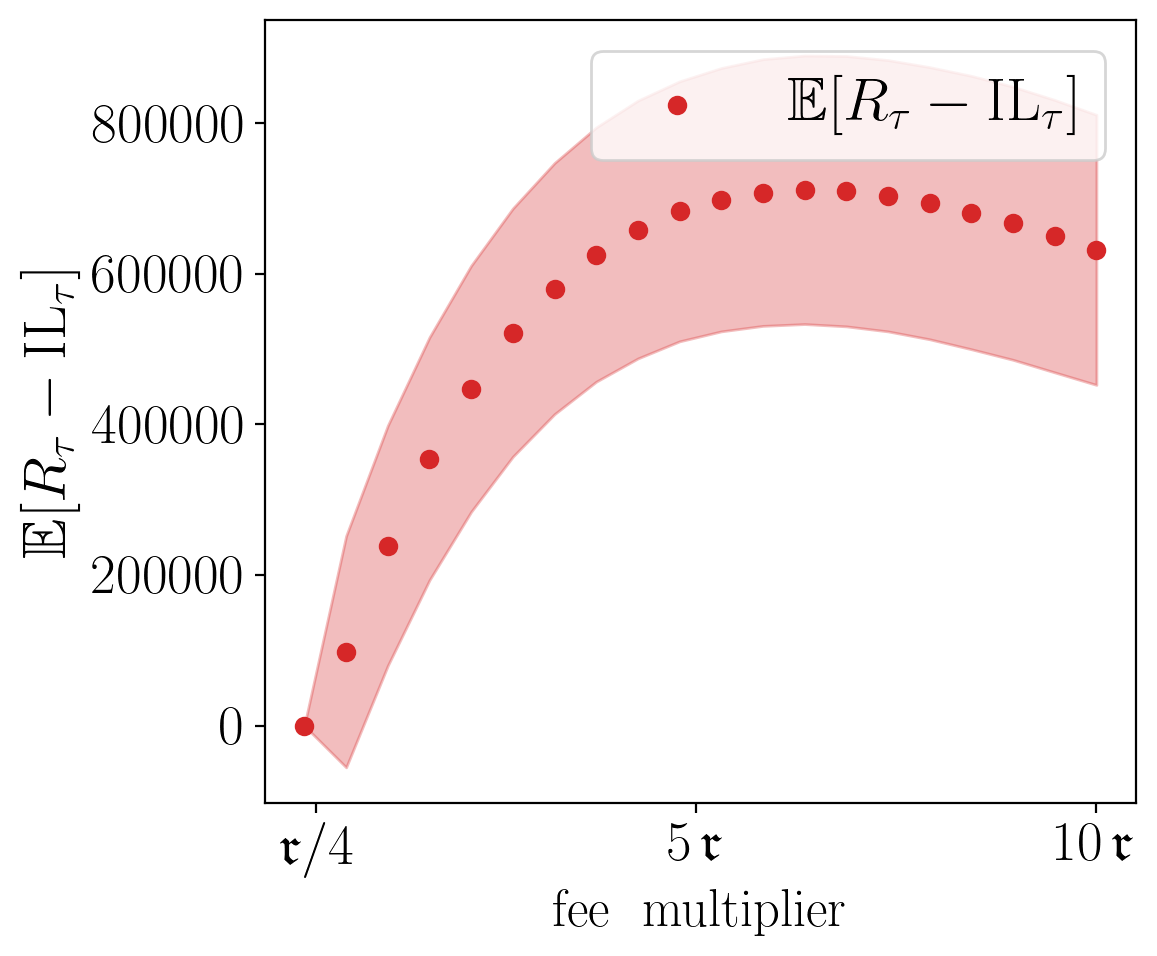

In [37]:
df_sorted = df.sort_values(by='parameter')
x = df_sorted['parameter']
y = df_sorted['Mean perf']
std = df_sorted['std perf']

fig, axs = plt.subplots(1, 1, sharex=True, figsize=(6,5))

# Scatter plot
plt.scatter(multiplier, y, label=r'$\mathbb{E}[R_{\tau} - \mathrm{IL}_{\tau}]$', color='tab:red')

# Error band
plt.fill_between(multiplier, y - std, y + std, color='tab:red', alpha=0.3)

# Labels and formatting
plt.xlabel(r'$\mathrm{fee}~~\mathrm{multiplier}$', fontsize=fsL)
plt.ylabel(r'$\mathbb{E}[R_{\tau} - \mathrm{IL}_{\tau}]$', fontsize=fsL+3)
plt.xticks([0.25, 5, 10], [r'$\mathfrak{r}/4$', r'$5\,\mathfrak{r}$', r'$10\,\mathfrak{r}$'])

plt.tight_layout()
plt.legend(fontsize=fsL+3, loc='upper right')
plt.savefig(f'figures/fee-multiplier-and-performance.pdf', format="pdf", dpi=dpi)
plt.show()

#### Earlier part only

In [38]:
multiplier = np.linspace(0.1,1, num= 20)
latex_output, df = stress_parameter(multiplier=multiplier, text_array = multiplier, 
                          params_type = 'lp', parameter_to_stress = 'fees_coeff', seed = 123, verbose=True)

100%|███████████████████████████████████████| 20/20 [01:27<00:00,  4.37s/it]


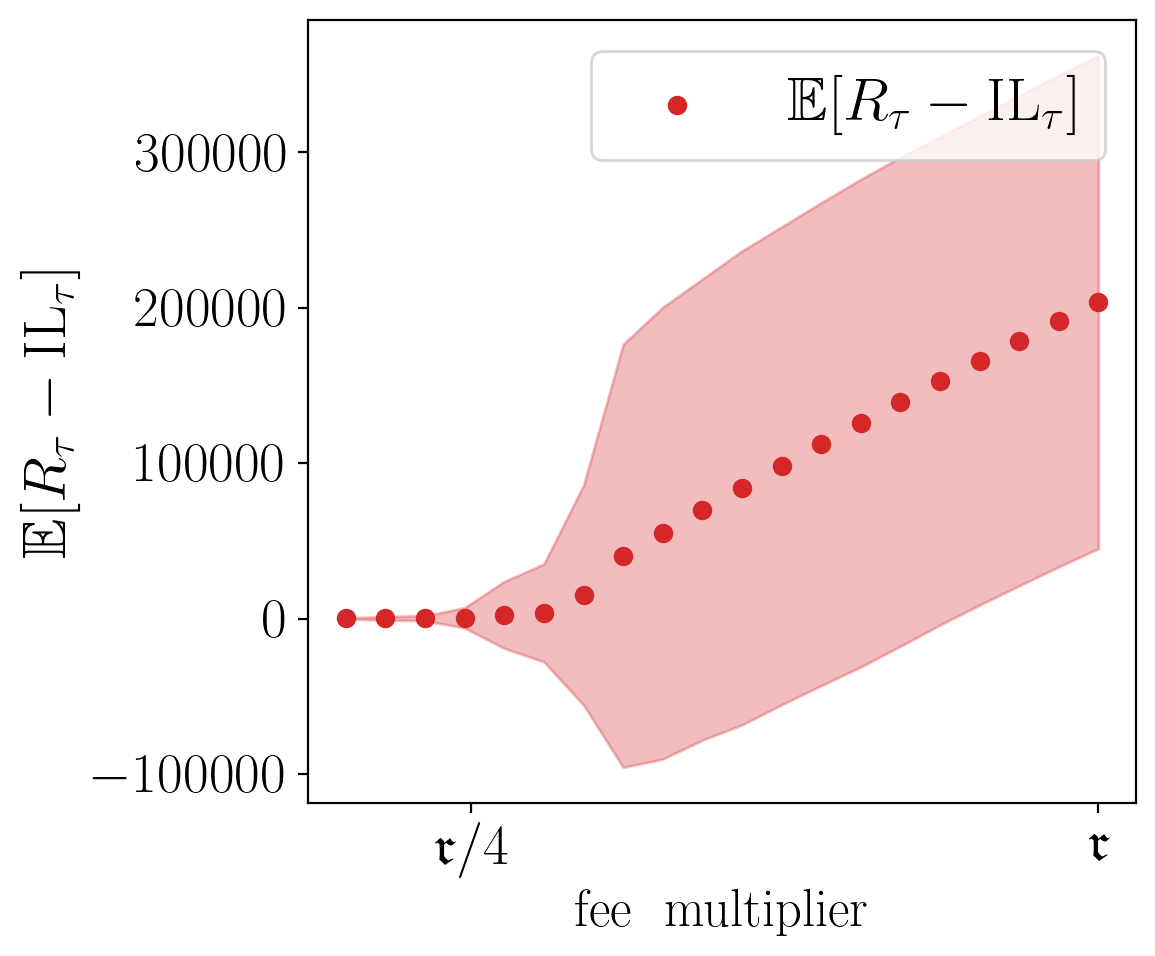

In [39]:
df_sorted = df.sort_values(by='parameter')
x = df_sorted['parameter']
y = df_sorted['Mean perf']
std = df_sorted['std perf']

fig, axs = plt.subplots(1, 1, sharex=True, figsize=(6,5))

# Scatter plot
plt.scatter(multiplier, y, label=r'$\mathbb{E}[R_{\tau} - \mathrm{IL}_{\tau}]$', color='tab:red')

# Error band
plt.fill_between(multiplier, y - std, y + std, color='tab:red', alpha=0.3)

# Labels and formatting
plt.xlabel(r'$\mathrm{fee}~~\mathrm{multiplier}$', fontsize=fsL)
plt.ylabel(r'$\mathbb{E}[R_{\tau} - \mathrm{IL}_{\tau}]$', fontsize=fsL+3)
plt.xticks([0.25, 1], [r'$\mathfrak{r}/4$', r'$\mathfrak{r}$'])

plt.tight_layout()
plt.legend(fontsize=fsL+3, loc='upper right')
plt.savefig(f'figures/fee-multiplier-and-performance_zoomed.pdf', format="pdf", dpi=dpi)
plt.show()

# Understanding the arbitrageurs better

In [20]:
multiplier = np.linspace(0.1,10, num= 20)
latex_output, df = stress_parameter(multiplier=multiplier, text_array = multiplier, 
                          params_type = 'lp', parameter_to_stress = 'a2', seed = 123, verbose=True)

100%|███████████████████████████████████████████| 20/20 [01:23<00:00,  4.15s/it]


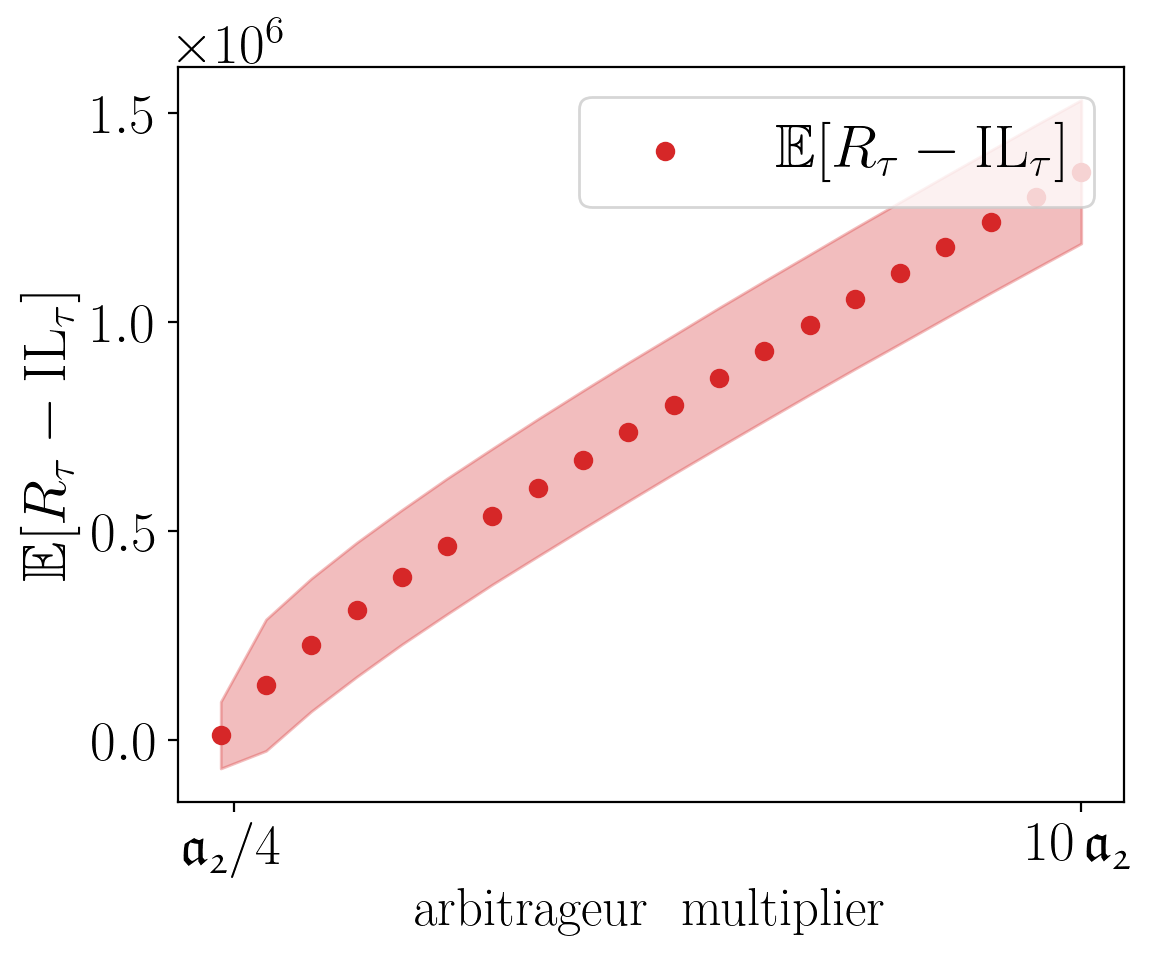

In [21]:
df_sorted = df.sort_values(by='parameter')
x = df_sorted['parameter']
y = df_sorted['Mean perf']
std = df_sorted['std perf']

fig, axs = plt.subplots(1, 1, sharex=True, figsize=(6,5))

# Scatter plot
plt.scatter(multiplier, y, label=r'$\mathbb{E}[R_{\tau} - \mathrm{IL}_{\tau}]$', color='tab:red')

# Error band
plt.fill_between(multiplier, y - std, y + std, color='tab:red', alpha=0.3)

# Labels and formatting
plt.xlabel(r'$\mathrm{arbitrageur}~~\mathrm{multiplier}$', fontsize=fsL)
plt.ylabel(r'$\mathbb{E}[R_{\tau} - \mathrm{IL}_{\tau}]$', fontsize=fsL+3)
plt.xticks([0.25, 10], [r'$\mathfrak{a_2}/4$', r'$10\,\mathfrak{a_2}$'])

plt.tight_layout()
plt.legend(fontsize=fsL+3, loc='upper right')
#plt.savefig(f'figures/a2-multiplier-and-performance.pdf', format="pdf", dpi=dpi)
plt.show()